In [9]:
from scipy.integrate import solve_ivp

import numpy as np

import sk_dsp_comm.sigsys as ss


def sigmoid(u):

    return np.tanh(u)

def N_oscillators(t, y, N, h_ex_rand, h_in_rand, 
                        coupling_matrix_EE, coupling_matrix_EI, cconst_E, cconst_I, pars, sr, time_stop, pert, pert_osc_list):
        
    tau_ex, tau_in, c2, c4 = pars
    
    time_index = int(t*sr)
    
    if time_index >= time_stop*sr:
        dydt = np.zeros(2*N)
        
        return dydt

    # Separate Variables
    y_ex = y[:-1:2]
    y_in = y[1::2]
    dy_ex, dy_in = np.zeros(N), np.zeros(N)
    dydt = np.zeros(2*N)

    for osc in np.arange(N):
        coup_EE = cconst_E*sigmoid(sum(coupling_matrix_EE[:, osc] * y_ex))
        coup_EI = cconst_I*sigmoid(sum(coupling_matrix_EI[:, osc] * y_ex))

        if osc in pert_osc_list:  # Changed from == to 'in'
                
            dy_ex[osc] = (pert[time_index] - y_ex[osc] - c2*sigmoid(y_in[osc]) + coup_EE)*tau_ex 
            dy_in[osc] = (h_in_rand[osc]   - y_in[osc] - c4*sigmoid(y_in[osc]) + coup_EI)*tau_in
            
        else:
                
            dy_ex[osc] = (h_ex_rand[osc]   - y_ex[osc] - c2*sigmoid(y_in[osc]) + coup_EE)*tau_ex 
            dy_in[osc] = (h_in_rand[osc]   - y_in[osc] - c4*sigmoid(y_in[osc]) + coup_EI)*tau_in
            
    # Combine Variables
    dydt[:-1:2] = dy_ex
    dydt[1: :2] = dy_in
    
    return dydt

def get_hexagon_centers_sorted(layers):
    """
    Generate hexagon centers sorted by layer (distance from origin)
    Returns list of (x, y, q, r, s, distance) tuples
    """
    center_spacing = 1.0
    centers = []
    
    for q in range(-layers+1, layers):
        for r in range(-layers+1, layers):
            s = -q - r
            if max(abs(q), abs(r), abs(s)) <= layers-1:
                x = center_spacing * (3/2 * q)
                y = center_spacing * (np.sqrt(3)/2 * q + np.sqrt(3) * r)
                distance = max(abs(q), abs(r), abs(s))
                centers.append((x, y, q, r, s, distance))
    
    # Sort by distance (layer), then by angle
    centers_sorted = sorted(centers, key=lambda c: (c[5], np.arctan2(c[1], c[0])))
    return centers_sorted
  

def create_connectivity_matrix(layers):
    """
    Create connectivity/adjacency matrix for hexagonal lattice
    Returns NxN matrix where entry (i,j) = 1 if hexagons i and j are neighbors
    """
    centers = get_hexagon_centers_sorted(layers)
    N = len(centers)
    
    # Initialize connectivity matrix
    connectivity = np.zeros((N, N), dtype=int)
    
    # Create a mapping from (q, r, s) coordinates to index
    coord_to_index = {}
    for i, (x, y, q, r, s, dist) in enumerate(centers):
        coord_to_index[(q, r, s)] = i
    
    # In hexagonal/cube coordinates, the 6 neighbors of (q, r, s) are:
    # (q+1, r-1, s), (q+1, r, s-1), (q, r+1, s-1)
    # (q-1, r+1, s), (q-1, r, s+1), (q, r-1, s+1)
    neighbor_offsets = [
        (1, -1, 0),   # East
        (1, 0, -1),   # Northeast
        (0, 1, -1),   # Northwest
        (-1, 1, 0),   # West
        (-1, 0, 1),   # Southwest
        (0, -1, 1)    # Southeast
    ]
    
    # For each hexagon, check its 6 potential neighbors
    for i, (x, y, q, r, s, dist) in enumerate(centers):
        for dq, dr, ds in neighbor_offsets:
            neighbor_coords = (q + dq, r + dr, s + ds)
            
            # Check if neighbor exists in our lattice
            if neighbor_coords in coord_to_index:
                j = coord_to_index[neighbor_coords]
                connectivity[i, j] = 1
    
    return connectivity, centers

# Number of hexagonal layers
L = 3

# Number of oscillators
N = 3*L*(L-1)+1

print(N)

# Excitatory input parameter
h_ex_0 = -6.4
h_in_0 = -4.0

eps          = 0.01
RANDOM_STATE = 11111
np.random.seed(RANDOM_STATE)
random_vals        = eps*np.random.normal(0,1,size=N)
random_vals_sorted = np.sort(random_vals)
h_ex_rand = h_ex_0 - random_vals_sorted
h_in_rand = h_in_0 - eps*np.random.normal(0,1,size=N)

# Parameters
pars = (1, 2.5, 10, 0) # Homoclinic

coupling_strength_EE, coupling_strength_EI = 5., 10.

frac_EE, frac_EI = 0.2, 0.0

# Coupling
coupling_matrix_EE_ini, _ = create_connectivity_matrix(L)
coupling_matrix_EI_ini    = coupling_matrix_EE_ini.copy()

coupling_matrix_EE = coupling_matrix_EE_ini*frac_EE
coupling_matrix_EI = coupling_matrix_EI_ini*frac_EI

np.fill_diagonal(coupling_matrix_EE, 1)
np.fill_diagonal(coupling_matrix_EI, 1)


# Time array
time_stop = 10
sr        = 1000
samples   = time_stop*sr
time      = np.linspace(start=0, stop=time_stop, num=samples)

pulse_fre = 0.5
pulse_wid = 0.2
pulse_amp = 1.0

# Initial conditions:
y_ini = np.random.normal(size=2*N)

pert      = h_ex_0 + pulse_amp*ss.rect(np.mod(time, 1/pulse_fre)-(1/pulse_fre)/2+pulse_wid/2, pulse_wid)

pert_osc  =[0]

solution    = solve_ivp(fun=N_oscillators, t_span=(0, time_stop), y0=y_ini, t_eval=time,  
                args=(N, h_ex_rand, h_in_rand,  
                    coupling_matrix_EE, 
                    coupling_matrix_EI, 
                    coupling_strength_EE, 
                    coupling_strength_EI, 
                    pars, sr, time_stop, pert, pert_osc), 
                method='BDF', max_step=0.1)

t, y_pert = solution.t, solution.y.T

y_ex_only = y_pert[:,::2]

print('Complete')


19
Complete


In [10]:
y_ex_only.shape

(50000, 19)

# Claude

Number of oscillators: 19
Running simulation...
Simulation complete!
Creating animation...
Final frame saved!
Snapshot figure saved!

All visualizations complete!
Files saved to /mnt/user-data/outputs/


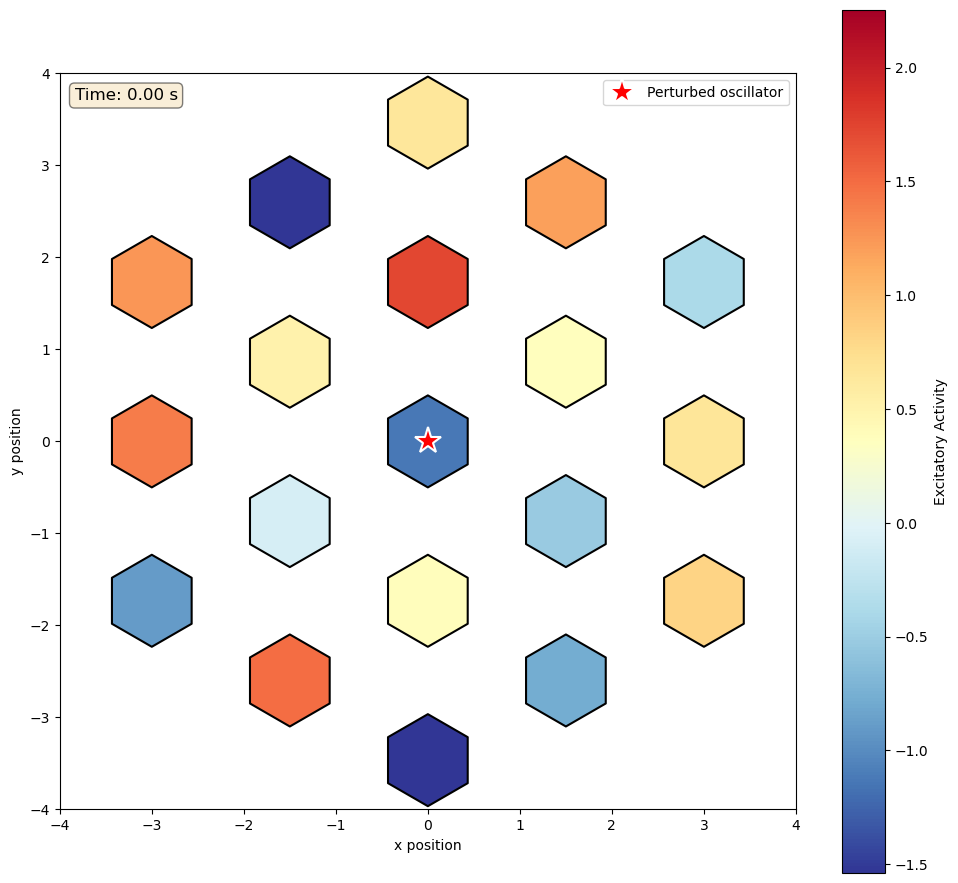

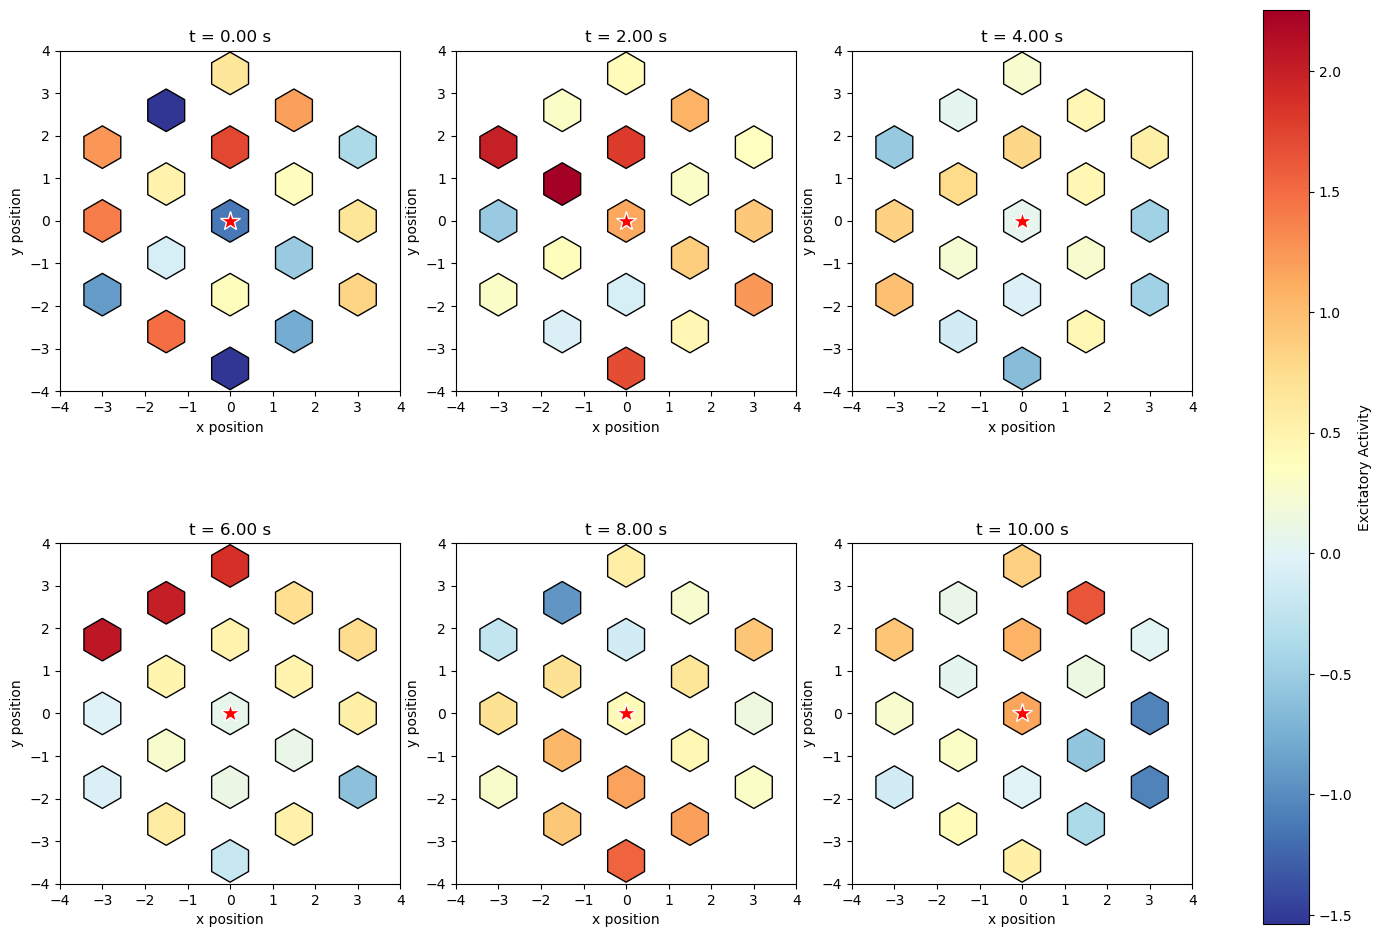

In [12]:
from scipy.integrate import solve_ivp
import numpy as np
import sk_dsp_comm.sigsys as ss
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection

def sigmoid(u):
    return np.tanh(u)

def N_oscillators(t, y, N, h_ex_rand, h_in_rand, 
                        coupling_matrix_EE, coupling_matrix_EI, cconst_E, cconst_I, pars, sr, time_stop, pert, pert_osc_list):
        
    tau_ex, tau_in, c2, c4 = pars
    
    time_index = int(t*sr)
    
    if time_index >= time_stop*sr:
        dydt = np.zeros(2*N)
        
        return dydt

    # Separate Variables
    y_ex = y[:-1:2]
    y_in = y[1::2]
    dy_ex, dy_in = np.zeros(N), np.zeros(N)
    dydt = np.zeros(2*N)

    for osc in np.arange(N):
        coup_EE = cconst_E*sigmoid(sum(coupling_matrix_EE[:, osc] * y_ex))
        coup_EI = cconst_I*sigmoid(sum(coupling_matrix_EI[:, osc] * y_ex))

        if osc in pert_osc_list:  # Changed from == to 'in'
                
            dy_ex[osc] = (pert[time_index] - y_ex[osc] - c2*sigmoid(y_in[osc]) + coup_EE)*tau_ex 
            dy_in[osc] = (h_in_rand[osc]   - y_in[osc] - c4*sigmoid(y_in[osc]) + coup_EI)*tau_in
            
        else:
                
            dy_ex[osc] = (h_ex_rand[osc]   - y_ex[osc] - c2*sigmoid(y_in[osc]) + coup_EE)*tau_ex 
            dy_in[osc] = (h_in_rand[osc]   - y_in[osc] - c4*sigmoid(y_in[osc]) + coup_EI)*tau_in
            
    # Combine Variables
    dydt[:-1:2] = dy_ex
    dydt[1::2] = dy_in  # Fixed: removed extra space
    
    return dydt

def get_hexagon_centers_sorted(layers):
    """
    Generate hexagon centers sorted by layer (distance from origin)
    Returns list of (x, y, q, r, s, distance) tuples
    """
    center_spacing = 1.0
    centers = []
    
    for q in range(-layers+1, layers):
        for r in range(-layers+1, layers):
            s = -q - r
            if max(abs(q), abs(r), abs(s)) <= layers-1:
                x = center_spacing * (3/2 * q)
                y = center_spacing * (np.sqrt(3)/2 * q + np.sqrt(3) * r)
                distance = max(abs(q), abs(r), abs(s))
                centers.append((x, y, q, r, s, distance))
    
    # Sort by distance (layer), then by angle
    centers_sorted = sorted(centers, key=lambda c: (c[5], np.arctan2(c[1], c[0])))
    return centers_sorted
  

def create_connectivity_matrix(layers):
    """
    Create connectivity/adjacency matrix for hexagonal lattice
    Returns NxN matrix where entry (i,j) = 1 if hexagons i and j are neighbors
    """
    centers = get_hexagon_centers_sorted(layers)
    N = len(centers)
    
    # Initialize connectivity matrix
    connectivity = np.zeros((N, N), dtype=int)
    
    # Create a mapping from (q, r, s) coordinates to index
    coord_to_index = {}
    for i, (x, y, q, r, s, dist) in enumerate(centers):
        coord_to_index[(q, r, s)] = i
    
    # In hexagonal/cube coordinates, the 6 neighbors of (q, r, s) are:
    # (q+1, r-1, s), (q+1, r, s-1), (q, r+1, s-1)
    # (q-1, r+1, s), (q-1, r, s+1), (q, r-1, s+1)
    neighbor_offsets = [
        (1, -1, 0),   # East
        (1, 0, -1),   # Northeast
        (0, 1, -1),   # Northwest
        (-1, 1, 0),   # West
        (-1, 0, 1),   # Southwest
        (0, -1, 1)    # Southeast
    ]
    
    # For each hexagon, check its 6 potential neighbors
    for i, (x, y, q, r, s, dist) in enumerate(centers):
        for dq, dr, ds in neighbor_offsets:
            neighbor_coords = (q + dq, r + dr, s + ds)
            
            # Check if neighbor exists in our lattice
            if neighbor_coords in coord_to_index:
                j = coord_to_index[neighbor_coords]
                connectivity[i, j] = 1
    
    return connectivity, centers

# Number of hexagonal layers
L = 3

# Number of oscillators
N = 3*L*(L-1)+1

print(f"Number of oscillators: {N}")

# Excitatory input parameter
h_ex_0 = -6.4
h_in_0 = -4.0

eps          = 0.01
RANDOM_STATE = 11111
np.random.seed(RANDOM_STATE)
random_vals        = eps*np.random.normal(0,1,size=N)
random_vals_sorted = np.sort(random_vals)
h_ex_rand = h_ex_0 - random_vals_sorted
h_in_rand = h_in_0 - eps*np.random.normal(0,1,size=N)

# Parameters
pars = (1, 2.5, 10, 0) # Homoclinic

coupling_strength_EE, coupling_strength_EI = 5., 10.

frac_EE, frac_EI = 0.2, 0.0

# Coupling
coupling_matrix_EE_ini, centers = create_connectivity_matrix(L)
coupling_matrix_EI_ini    = coupling_matrix_EE_ini.copy()

coupling_matrix_EE = coupling_matrix_EE_ini*frac_EE
coupling_matrix_EI = coupling_matrix_EI_ini*frac_EI

np.fill_diagonal(coupling_matrix_EE, 1)
np.fill_diagonal(coupling_matrix_EI, 1)


# Time array
time_stop = 10
sr        = 1000
samples   = time_stop*sr
time      = np.linspace(start=0, stop=time_stop, num=samples)

pulse_fre = 0.5
pulse_wid = 0.2
pulse_amp = 1.0

# Initial conditions:
y_ini = np.random.normal(size=2*N)

pert      = h_ex_0 + pulse_amp*ss.rect(np.mod(time, 1/pulse_fre)-(1/pulse_fre)/2+pulse_wid/2, pulse_wid)

pert_osc  = [0]

print("Running simulation...")
solution    = solve_ivp(fun=N_oscillators, t_span=(0, time_stop), y0=y_ini, t_eval=time,  
                args=(N, h_ex_rand, h_in_rand,  
                    coupling_matrix_EE, 
                    coupling_matrix_EI, 
                    coupling_strength_EE, 
                    coupling_strength_EI, 
                    pars, sr, time_stop, pert, pert_osc), 
                method='BDF', max_step=0.1)

t, y_pert = solution.t, solution.y.T

y_ex_only = y_pert[:,::2]

print('Simulation complete!')

# ========== VISUALIZATION ==========

# Create figure for animation
fig, ax = plt.subplots(figsize=(10, 9))

# Extract hexagon positions
hex_positions = [(c[0], c[1]) for c in centers]

# Create hexagon patches
hex_size = 0.5
hexagons = []
for x, y in hex_positions:
    hexagon = RegularPolygon((x, y), numVertices=6, radius=hex_size, 
                             orientation=0, edgecolor='black', linewidth=1.5)
    hexagons.append(hexagon)

# Create patch collection
hex_collection = PatchCollection(hexagons, cmap='RdYlBu_r', edgecolors='black', linewidths=1.5)
ax.add_collection(hex_collection)

# Set initial colors
hex_collection.set_array(y_ex_only[0])

# Set color limits based on data range
vmin, vmax = np.percentile(y_ex_only, [1, 99])
hex_collection.set_clim(vmin, vmax)

# Add colorbar
cbar = plt.colorbar(hex_collection, ax=ax, label='Excitatory Activity')

# Highlight the perturbed oscillator
perturbed_x, perturbed_y = hex_positions[pert_osc[0]]
perturbed_marker = ax.plot(perturbed_x, perturbed_y, 'r*', markersize=20, 
                           markeredgecolor='white', markeredgewidth=1.5, 
                           label='Perturbed oscillator')[0]

# Set axis properties
ax.set_aspect('equal')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.legend(loc='upper right')

# Add time text
time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                   verticalalignment='top', fontsize=12,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Animation update function
def update(frame):
    # Downsample for smoother animation
    idx = frame * 10  # Show every 10th frame
    if idx >= len(y_ex_only):
        idx = len(y_ex_only) - 1
    
    hex_collection.set_array(y_ex_only[idx])
    time_text.set_text(f'Time: {t[idx]:.2f} s')
    return hex_collection, time_text

# Create animation
print("Creating animation...")
n_frames = len(y_ex_only) // 10
anim = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=True)

# Save animation
# print("Saving animation...")
# anim.save('test_hexagonal_wave.mp4', writer='ffmpeg', fps=20, dpi=100)
# print("Animation saved!")

plt.tight_layout()
plt.savefig('test_hexagonal_final_frame.png', dpi=150, bbox_inches='tight')
print("Final frame saved!")

# Create a static figure showing multiple time points
fig2, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

time_points = np.linspace(0, len(y_ex_only)-1, 6, dtype=int)

for i, idx in enumerate(time_points):
    ax = axes[i]
    
    # Create hexagons for this subplot
    hexagons_sub = []
    for x, y in hex_positions:
        hexagon = RegularPolygon((x, y), numVertices=6, radius=hex_size, 
                               orientation=0, edgecolor='black', linewidth=1)
        hexagons_sub.append(hexagon)
    
    hex_coll = PatchCollection(hexagons_sub, cmap='RdYlBu_r', edgecolors='black', linewidths=1)
    ax.add_collection(hex_coll)
    hex_coll.set_array(y_ex_only[idx])
    hex_coll.set_clim(vmin, vmax)
    
    # Mark perturbed oscillator
    ax.plot(perturbed_x, perturbed_y, 'r*', markersize=15, 
           markeredgecolor='white', markeredgewidth=1)
    
    ax.set_aspect('equal')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_title(f't = {t[idx]:.2f} s')
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')

plt.tight_layout()
plt.colorbar(hex_coll, ax=axes, label='Excitatory Activity')
plt.savefig('test_hexagonal_snapshots.png', dpi=150, bbox_inches='tight')
print("Snapshot figure saved!")

print("\nAll visualizations complete!")
print(f"Files saved to /mnt/user-data/outputs/")